In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [41]:
compiled_data = pd.read_csv('compiled_data.csv', parse_dates=['End_Date'], index_col='End_Date')[['Mean_Return', 'Volatility','Max_Return', 'Min_Return', 'kurtosis', 'skewness']]
garch_data = pd.read_csv('garch_data.csv', parse_dates=['End_Date'], index_col='End_Date')[['volatility_forecast',
       'annualized_volatility']]

In [42]:
garch_data['realized_volatility'] = garch_data['volatility_forecast'].shift(-1)

GARCH MONITORING COMPONENTS

In [43]:
def format_vol_change(input_vol_change):
    if input_vol_change > 0:
        return ":red[↑]"  # Streamlit red syntax
    elif input_vol_change < 0:
        return ":green[↓]"  # Streamlit green syntax
    else:
        return "→"

In [44]:
def transform_volatility(tail_days, prior_tail_days, text_file):
    #current volatility values
    tail_vol = round(garch_data['volatility_forecast'].iloc[-tail_days], 3)
    current_volatility_presentation = f"{tail_vol}%"

    #prior day volatility values
    prior_tail_vol = round(garch_data['volatility_forecast'].iloc[-prior_tail_days], 3)
    period_vol_change = round(tail_vol - prior_tail_vol, 3)
    period_vol_change_text = f"({period_vol_change}% from {text_file})"
    period_vol_change_arrow = format_vol_change(period_vol_change)
    period_vol_change_presentation = period_vol_change_text + " " + period_vol_change_arrow
    
    return current_volatility_presentation, period_vol_change_presentation

In [45]:
def transform_volatility_avg(tail_days):
    prior_tail_days = tail_days*2

    vol_d_avg = round(garch_data['volatility_forecast'].tail(tail_days).mean(), 3)
    vol_d_avg_presentation = f"{vol_d_avg}%"

    if len(garch_data) > prior_tail_days:
        prior_vol_d_avg = round(garch_data['volatility_forecast'].iloc[-prior_tail_days:-tail_days].mean(), 3)
        period_vol_d_change = round(vol_d_avg - prior_vol_d_avg, 3)
        period_vol_d_change_text = f"({period_vol_d_change}% from prior {tail_days}-day period)"
        period_vol_d_change_arrow = format_vol_change(period_vol_d_change)
        period_vol_d_change_presentation = period_vol_d_change_text + " " + period_vol_d_change_arrow
    else:
        period_vol_d_change_presentation ="No period information yet"

    return vol_d_avg_presentation, period_vol_d_change_presentation


In [ ]:
##CURRENT DAY CARD VALUES
vol_current, vol_current_change = transform_volatility(1, 2, 'yesterday')

##30 DAY CARD VALUES
vol_30d_avg, vol_30d_avg_presentation = transform_volatility_avg(30)

#60 trading day volatility average
vol_60d_avg, vol_60d_avg_presentation = transform_volatility_avg(60)

#90 trading day volatility average
vol_90d_avg, vol_90d_avg_presentation = transform_volatility_avg(90)

#180 trading day volatility average
vol_180d_avg, vol_180d_avg_presentation = transform_volatility_avg(180)

GARCH PLOTS

In [60]:
current_ann_volatility = round(garch_data['annualized_volatility'].iloc[-1], 2)

In [61]:
def create_forecast_validation_plot(garch_data, current_ann_volatility):
    # current annualized volatility plot
    fig, ax = plt.subplots(figsize=(16, 8))
    plt.style.use('seaborn-v0_8')
    ax.plot(garch_data.index, garch_data['annualized_volatility'], color = '#1f77b4',label='Annualized Volatility Forecast: Actual')
    ax.plot(garch_data.index, garch_data['annualized_volatility'].rolling(window=30).mean(), linewidth=1, linestyle=':', color='#62b4f3', label='Annualized Volatility Forecast: 30 Day Rolling Avg')
    ax.axhline(y=current_ann_volatility, color='#d62728', linestyle='--', label='Current Annualized Volatility: {}%'.format(current_ann_volatility))
    ax.axhline(y=garch_data['annualized_volatility'].mean(), color='g', linestyle='--', label='Average Annualized Volatility: {}%'.format(round(garch_data['annualized_volatility'].mean(),2)))
    ax.legend(fontsize=14)
    plt.title('GARCH Annualized Volatility Forecast', fontsize=16, fontweight='bold')
    plt.ylabel('Volatility (%)', fontsize=12)
    plt.yticks(np.arange(0, 80, 5))
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

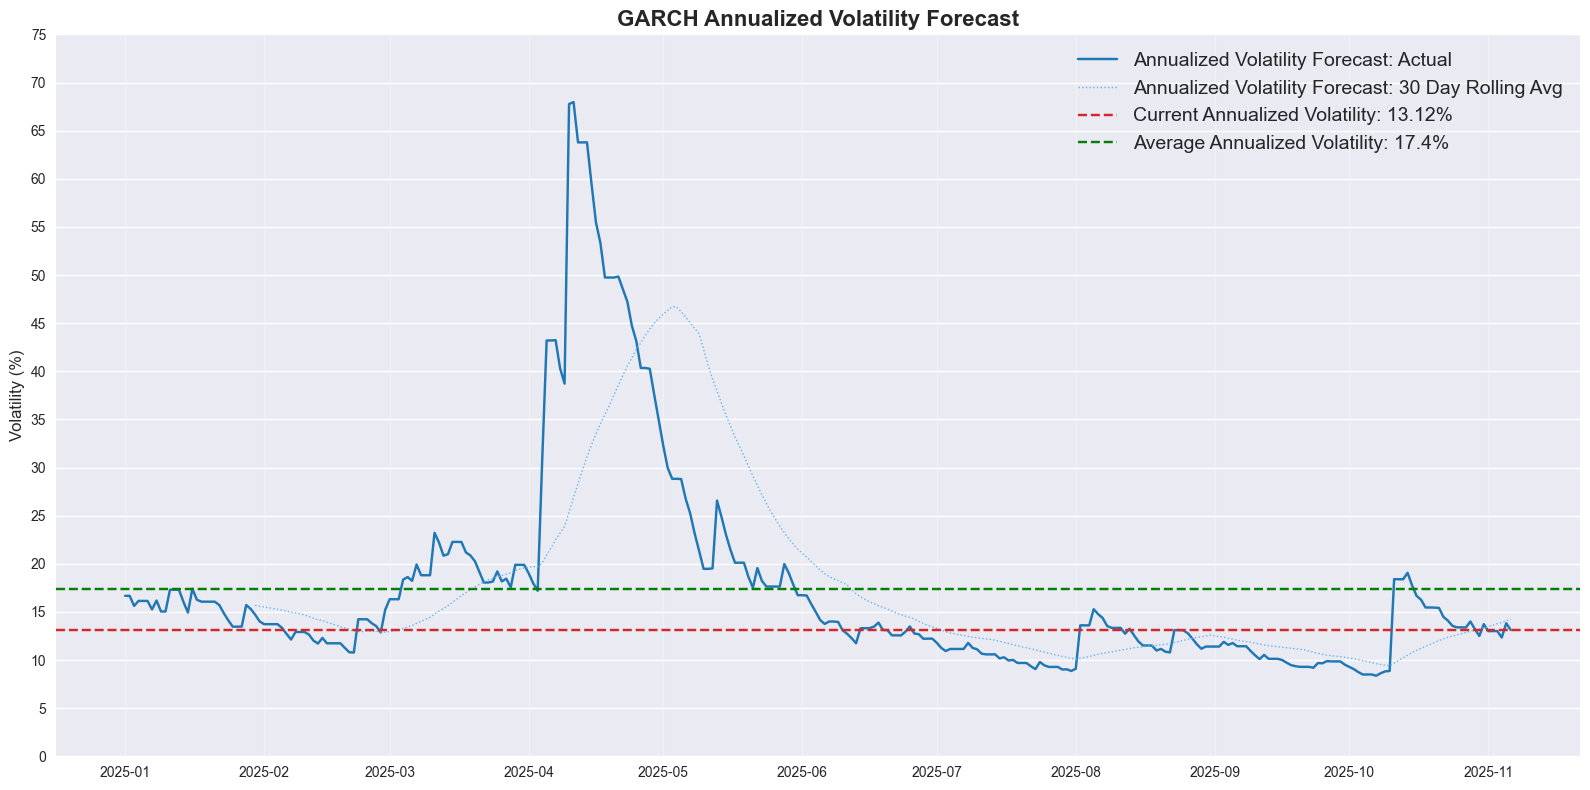

In [62]:
create_forecast_validation_plot(garch_data, current_ann_volatility)

In [66]:
def create_forecast_distribution_plot(garch_data, current_ann_volatility):
    fig, ax = plt.subplots(figsize=(6, 6))
    plt.style.use('seaborn-v0_8')
    ax.boxplot(garch_data['annualized_volatility'], vert=True, patch_artist=True, boxprops=dict(facecolor='#1f77b4', color='#1f77b4'), medianprops=dict(color='green', linestyle='--', linewidth=2 ))
    ax.scatter(1, current_ann_volatility, color='red', s=40, zorder=5, label='Current Annualized Volatility: {}%'.format(current_ann_volatility))
    ax.set_title('GARCH Annualized Volatility Forecast Distribution', fontsize=16, fontweight='bold')
    ax.set_ylabel('Volatility (%)', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks(np.arange(0, 80, 5))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

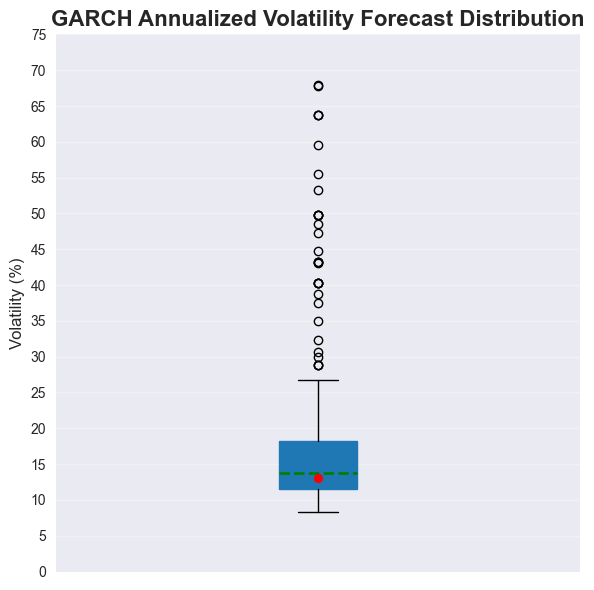

In [67]:
create_forecast_distribution_plot(garch_data, current_ann_volatility)

In [50]:

def create_forecast_validation_plot(garch_data):
    plot_data = garch_data.dropna()
    forecasts = plot_data['volatility_forecast']
    realized = plot_data['realized_volatility']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.style.use('seaborn-v0_8')
    
    # Scatter plot: forecasted vs realized
    ax.scatter(forecasts, realized, alpha=0.7, color='#1f77b4', s=30)
    
    # Perfect prediction line (45-degree)
    max_val = max(max(forecasts), max(realized))
    min_val = min(min(forecasts), min(realized))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
            label='Perfect Forecast Line')
    
    # Best fit line
    slope, intercept, r_value, p_value, std_err = stats.linregress(forecasts, realized)
    line = slope * forecasts + intercept
    ax.plot(forecasts, line, 'g-', linewidth=1.5, 
            label=f'Best Fit (R² = {r_value**2:.3f})')
    
    ax.set_xlabel('GARCH Forecast Volatility (%)', fontsize=12)
    ax.set_ylabel('Realized Volatility (%)', fontsize=12)
    ax.set_title('Forecast vs. Realized Volatility Validation', fontsize=16, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

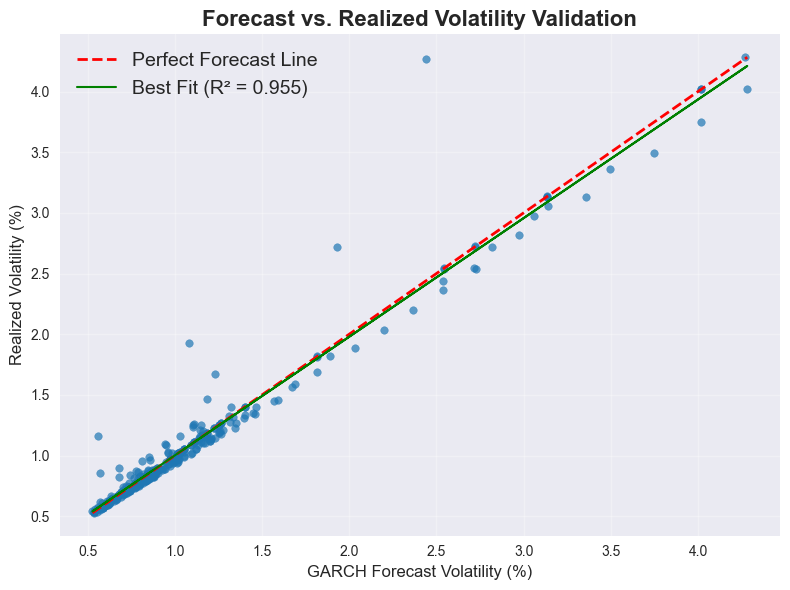

In [51]:
create_forecast_validation_plot(garch_data)